In [124]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
import scipy.io
import matplotlib.pyplot as plt

# mat_train = scipy.io.loadmat('/Users/isaaclee/Wildfire_Research/data/training_data_for_predicting_scalar_fire_area_recursively.mat')
# mat_test = scipy.io.loadmat('/Users/isaaclee/Wildfire_Research/data/testing_data_for_predicting_scalar_fire_area_recursively.mat')

# train = mat_train['training_data']
# test = mat_test['testing_data']

# X_train = train[:, 3:]
# y_train = train[:, 2]

# X_test = test[:, 3:]
# y_test = test[:, 2]

# model = xgb.XGBRegressor()
# model.fit(X_train, y_train)

# preds = model.predict(X_test)

# mape = mean_absolute_percentage_error(y_test, preds)
# print(f"MAPE: {mape:.3f}")

mat_train = scipy.io.loadmat('/Users/isaaclee/Wildfire_Research/data/training_data_for_predicting_scalar_fire_area_recursively.mat')
mat_test = scipy.io.loadmat('/Users/isaaclee/Wildfire_Research/data/testing_data_for_predicting_scalar_fire_area_recursively.mat')

train = mat_train['training_data']
test = mat_test['testing_data']

X_train = train[:, 3:]
y_train = train[:, 2]
X_test = test[:, 3:]
y_test = test[:, 2]

# log normalize
x3_log_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/lognorm_x3_log_max.npy')
y_train_log = np.log(y_train + 1) / x3_log_max
y_test_log = np.log(y_test + 1) / x3_log_max

model = xgb.XGBRegressor()
model.fit(X_train, y_train_log)

preds_log = model.predict(X_test)

# unnormalize
preds = np.exp(np.clip(preds_log, 0, None) * x3_log_max) - 1

mape = mean_absolute_percentage_error(y_test, preds)
print(f"MAPE: {mape:.3f}")

MAPE: 0.508


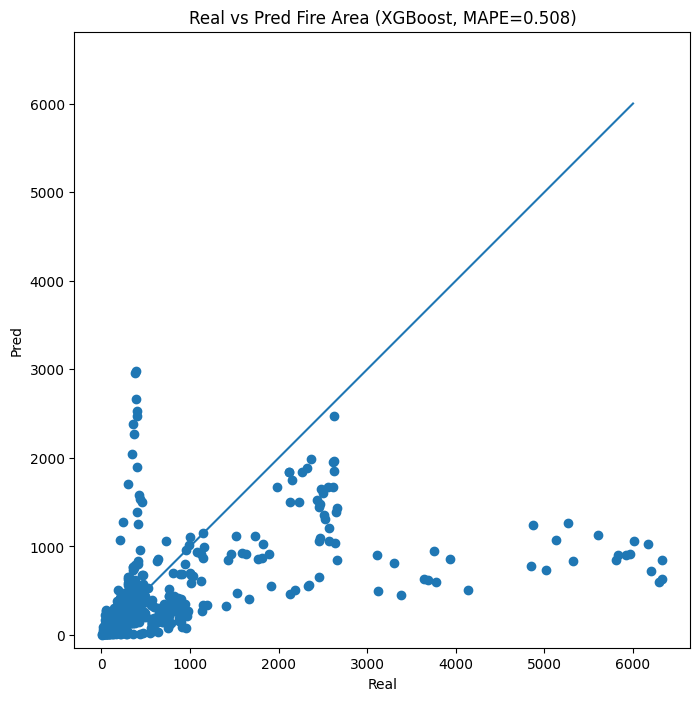

In [125]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, preds)
x=np.linspace(0,6000, 6000)
plt.axis("square")
plt.plot(x,x)
# plt.xlim(0,3000)
# plt.ylim(0,3000)
plt.title(f'Real vs Pred Fire Area (XGBoost, MAPE={mape:.3f})')
plt.xlabel('Real')
plt.ylabel('Pred')
plt.show()

In [ ]:
import numpy as np
import xgboost as xgb
import scipy.io
import os

# Training

mat_train = scipy.io.loadmat('/Users/isaaclee/Wildfire_Research/data/training_data_for_predicting_scalar_fire_area_recursively.mat')
train = mat_train['training_data']

X_train = train[:, 3:]
y_train = train[:, 2]

x3_log_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/lognorm_x3_log_max.npy')

y_train_log = np.log(y_train + 1) / x3_log_max # normalize

model = xgb.XGBRegressor()
model.fit(X_train, y_train_log)

# Recursive Sampling

test_data_dir = "/Users/isaaclee/Wildfire_Research/validation_case_data_and_preparation/test_fire_data_npy"
output_dir = "/Users/isaaclee/Wildfire_Research/xgboost_recursive_results/"
os.makedirs(output_dir, exist_ok=True)
x_dim = 3

for filename in os.listdir(test_data_dir):
    if filename.endswith('.npy'):
        condition_matrix = np.load(f"{test_data_dir}/{filename}")
        condition_matrix = condition_matrix[:, x_dim:]

        num_timesteps = condition_matrix.shape[0]
        fire_area_matrix = np.zeros([num_timesteps])

        for i in range(num_timesteps):
            conditions = condition_matrix[i, :].copy()

            if i == 1:
                conditions[0] = fire_area_matrix[i-1] / 19000
            elif i > 1:
                conditions[0] = fire_area_matrix[i-1] / 19000
                conditions[1] = fire_area_matrix[i-2] / 14000

            pred_log = model.predict(conditions.reshape(1, -1))[0]
            pred = np.exp(max(pred_log, 0) * x3_log_max) - 1  # unnormalize
            fire_area_matrix[i] = pred

        np.save(output_dir + f'{filename[:-25]}_xgb_fire_area_matrix.npy', fire_area_matrix)

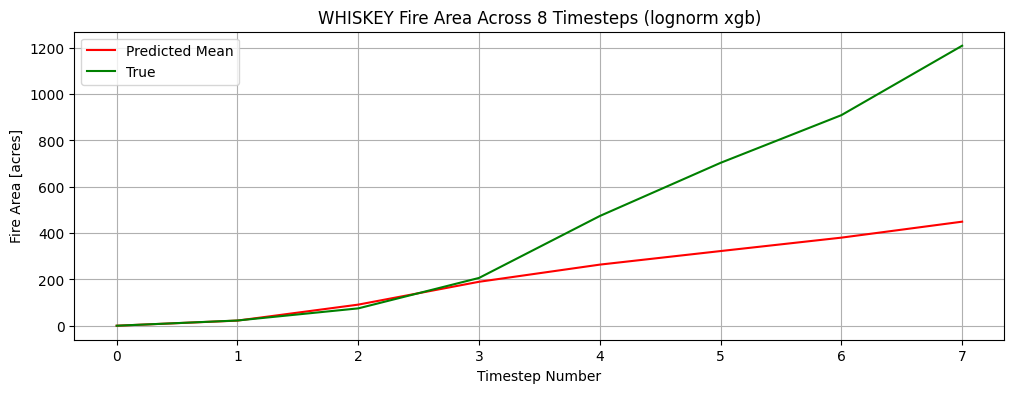

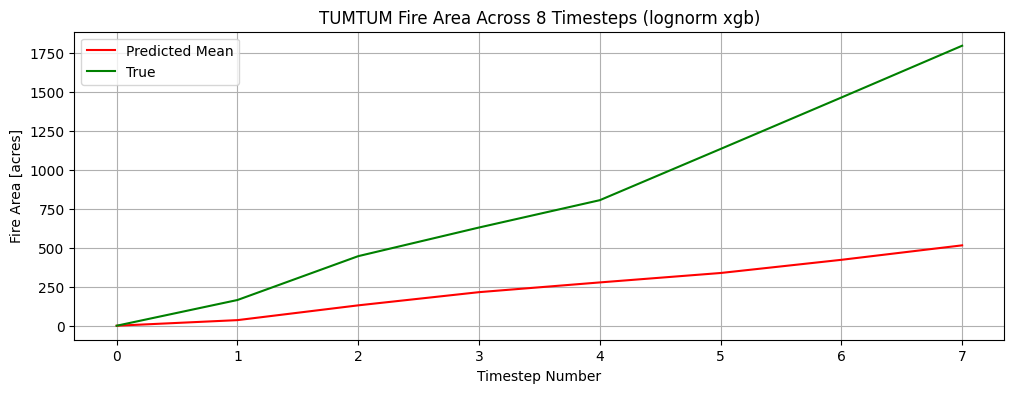

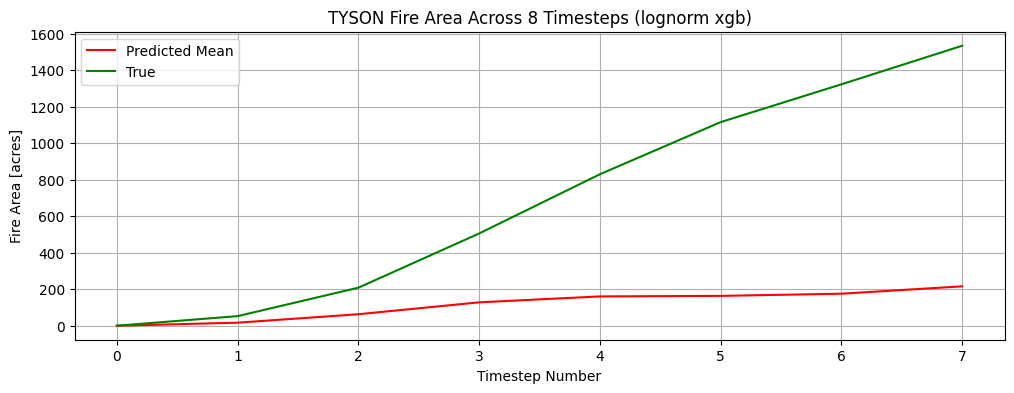

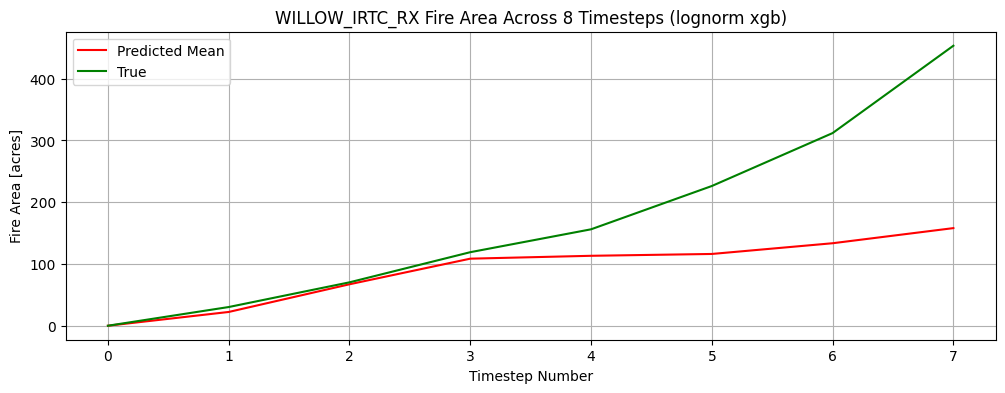

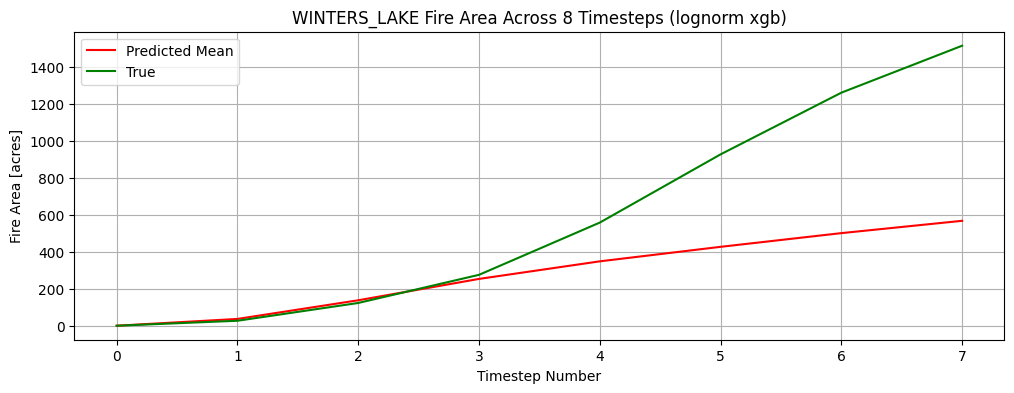

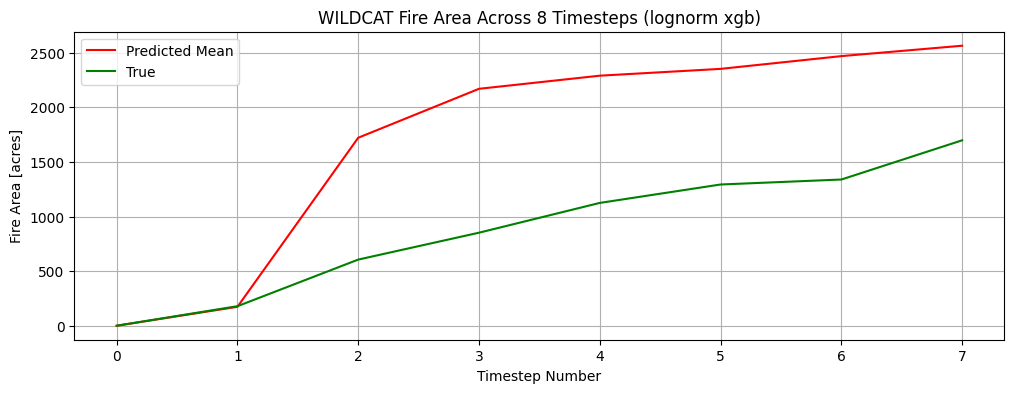

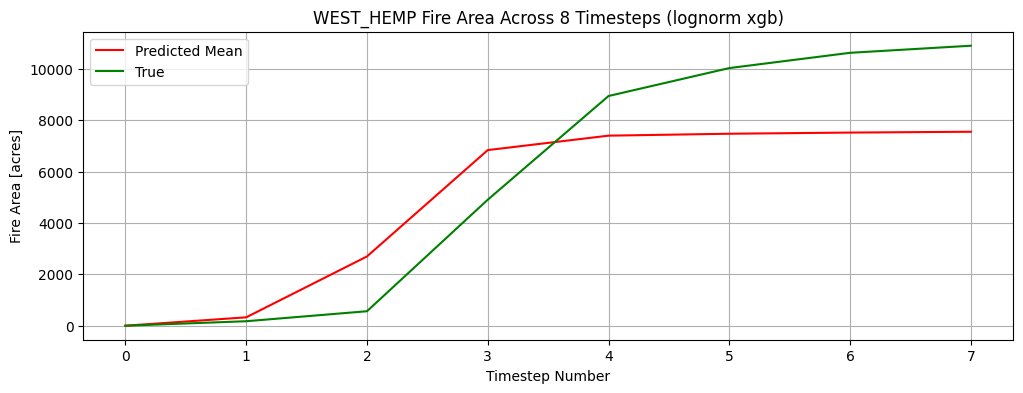

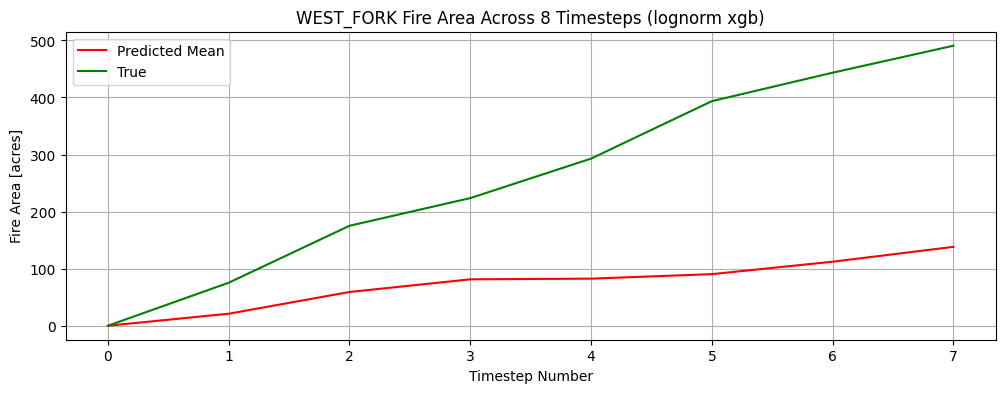

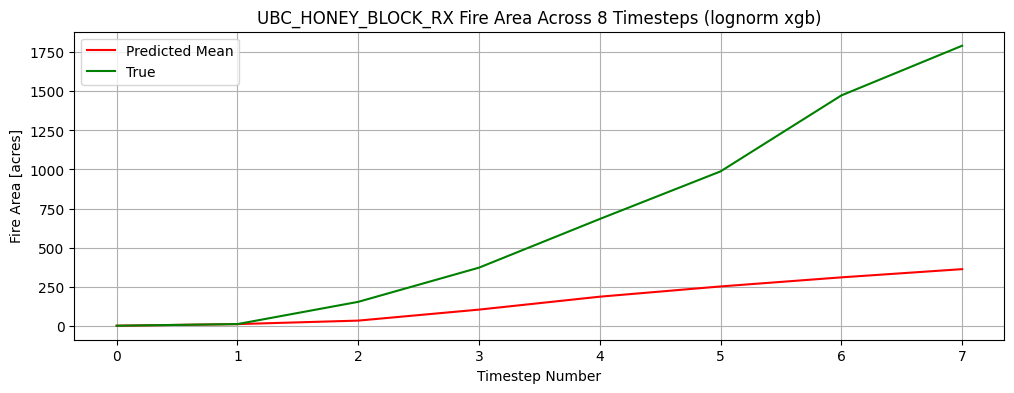

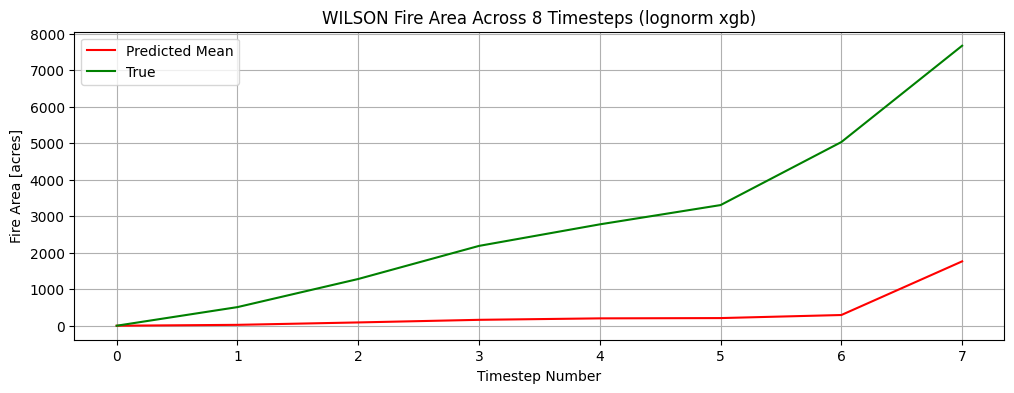

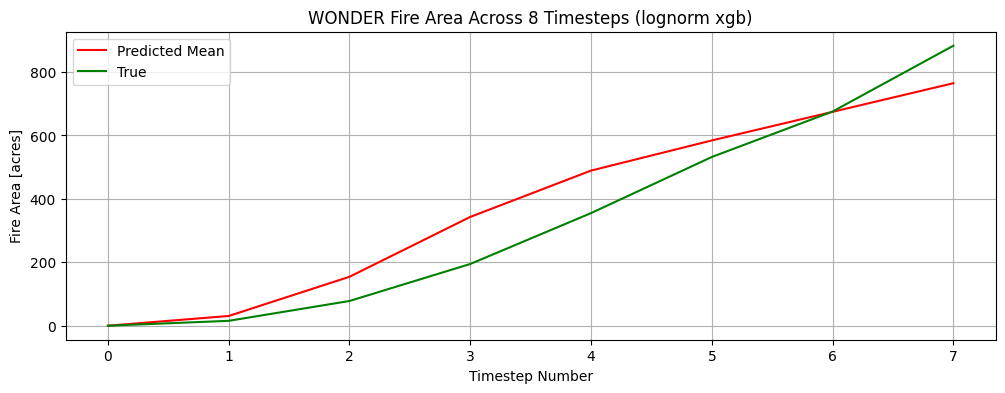

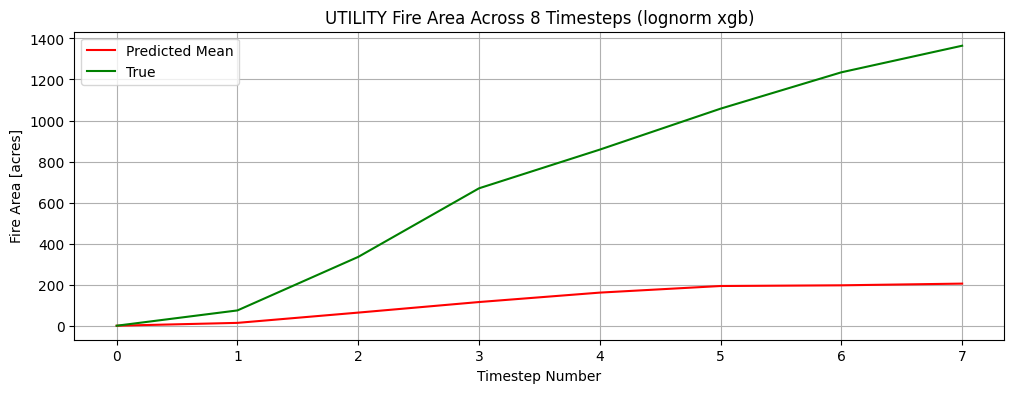

In [127]:
fires = ['WHISKEY', 'TUMTUM', 'TYSON', 'WILLOW_IRTC_RX', 'WINTERS_LAKE', 'WILDCAT', 'WEST_HEMP', 'WEST_FORK', 'UBC_HONEY_BLOCK_RX', 'WILSON', 'WONDER', 'UTILITY']

for fire_name in fires:
    fire_area_growth_matrix = np.load(f'{output_dir}/{fire_name}_xgb_fire_area_matrix.npy')
    #print(fire_area_growth_matrix.shape)

    area = np.sum(fire_area_growth_matrix[:], axis=0)
    #print(area)
    # print(f"Final predicted mean area: {np.mean(area)}")
    pred_area = np.mean(area)

    condition_matrix = np.load(f"/Users/isaaclee/Wildfire_Research/validation_case_data_and_preparation/test_fire_data_npy/{fire_name}_validation_case_data.npy")
    real_fire_area_growth = condition_matrix[:, 2]

    target_area = np.sum(real_fire_area_growth)
    # print(f"Target area: {target_area}")

    pred_fire_area = fire_area_growth_matrix.copy()
    real_fire_area = real_fire_area_growth.copy()

    for i in range(1, 7):
        pred_fire_area[i] = fire_area_growth_matrix[i] + pred_fire_area[i-1]
        real_fire_area[i] = real_fire_area_growth[i] + real_fire_area[i-1]

    pred_fire_area = np.insert(pred_fire_area, 0, 0)
    real_fire_area = np.insert(real_fire_area, 0, 0)

    # print(f"Real fire area: {real_fire_area}")
    # print(f"Predicted fire area: {pred_fire_area}")

    plt.figure(figsize=(12,4))
    plt.title(f'{fire_name} Fire Area Across 8 Timesteps (lognorm xgb)')
    plt.xlabel('Timestep Number')
    plt.xticks(range(0, 8))
    plt.ylabel('Fire Area [acres]')
    plt.grid(True)
    plt.plot(pred_fire_area, color='red', label='Predicted Mean')
    plt.plot(real_fire_area, color='green', label='True')
    plt.legend()
    plt.show()